# Machine-Learning In-Class Exercise - Wine Quality Prediction

**Developer:** Lenny Paz

**Course:** Artificial Intelligence Applications

**Program Requirements (Note: Here, in no particular sequence!):**

1. Get
2. Clean (if needed)
3. Prepare
4. Analyze
5. Display/Visualize
6. Identify correlations
7. Create classifications (i.e., "good" or "bad")
8. Make predictions (i.e., "quality" score)

**Note: Review Assignments 2-4, Project 1, the course textbook, as well as online resources!**

In [1]:
# 1. import necessary modules
import sys
import os
import pandas as pd

# for analyzing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# for plots
import matplotlib.pyplot as plt
import seaborn as sns

print(sys.version) # print python version
print(os.environ['CONDA_DEFAULT_ENV']) # print conda environment

3.9.25 (main, Nov  3 2025, 22:44:01) [MSC v.1929 64 bit (AMD64)]
testenv


In [2]:
# 2. get wine quality data: consult: http://www.vinhoverde.pt/en/ or reference [Cortez et al., 2009]
# link: https://archive.ics.uci.edu/dataset/186/wine+quality
wine_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"

# 3. read csv file into dataframe
df = pd.read_csv(wine_url, sep=';')

# Display Dataframe Characteristics

In [3]:
# 4. print number of rows and columns

df.shape

(1599, 12)

In [4]:
# 5. Use Pandas DataFrame info() Method:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [5]:
# 6. print dataframe statistics summary (format entire dataframe to two decimal places)

pd.options.display.float_format = "{:,.2f}".format
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,"1,599.00","1,599.00","1,599.00","1,599.00","1,599.00","1,599.00","1,599.00","1,599.00","1,599.00","1,599.00","1,599.00","1,599.00"
mean,8.32,0.53,0.27,2.54,0.09,15.87,46.47,1.00,3.31,0.66,10.42,5.64
std,1.74,0.18,0.19,1.41,0.05,10.46,32.90,0.00,0.15,0.17,1.07,0.81
min,4.60,0.12,0.00,0.90,0.01,1.00,6.00,0.99,2.74,0.33,8.40,3.00
25%,7.10,0.39,0.09,1.90,0.07,7.00,22.00,1.00,3.21,0.55,9.50,5.00
50%,7.90,0.52,0.26,2.20,0.08,14.00,38.00,1.00,3.31,0.62,10.20,6.00
75%,9.20,0.64,0.42,2.60,0.09,21.00,62.00,1.00,3.40,0.73,11.10,6.00
max,15.90,1.58,1.00,15.50,0.61,72.00,289.00,1.00,4.01,2.00,14.90,8.00


In [6]:
# 7. print DataFrame attributes: index, columns, size, and shape

print(f"Index: {df.index}")
print(f"Columns: {df.columns}")
print(f"Shape: {df.shape}")
print(f"Size (rows x cols): {df.size}")

Index: RangeIndex(start=0, stop=1599, step=1)
Columns: Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')
Shape: (1599, 12)
Size (rows x cols): 19188


In [7]:
# 8. Display first and last five rows with one command!

df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.40,0.70,0.00,1.90,0.08,11.00,34.00,1.00,3.51,0.56,9.40,5
1,7.80,0.88,0.00,2.60,0.10,25.00,67.00,1.00,3.20,0.68,9.80,5
2,7.80,0.76,0.04,2.30,0.09,15.00,54.00,1.00,3.26,0.65,9.80,5
3,11.20,0.28,0.56,1.90,0.07,17.00,60.00,1.00,3.16,0.58,9.80,6
4,7.40,0.70,0.00,1.90,0.08,11.00,34.00,1.00,3.51,0.56,9.40,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.20,0.60,0.08,2.00,0.09,32.00,44.00,0.99,3.45,0.58,10.50,5
1595,5.90,0.55,0.10,2.20,0.06,39.00,51.00,1.00,3.52,0.76,11.20,6
1596,6.30,0.51,0.13,2.30,0.08,29.00,40.00,1.00,3.42,0.75,11.00,6
1597,5.90,0.65,0.12,2.00,0.07,32.00,44.00,1.00,3.57,0.71,10.20,5


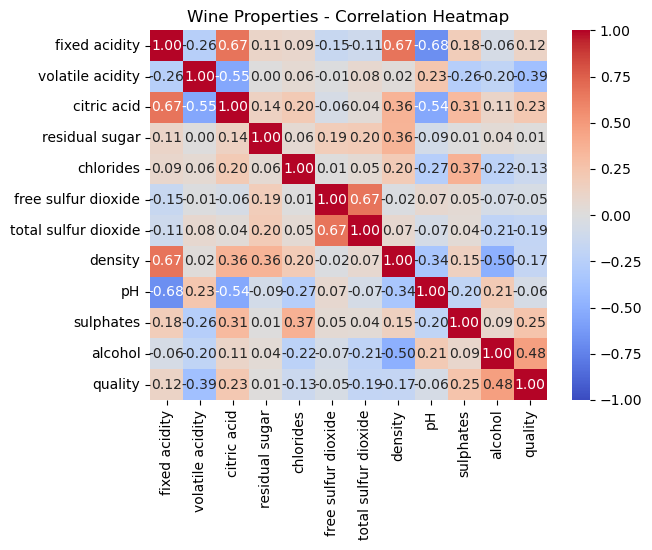

In [8]:
# 9. display correlation matrix

# Note:
# coolwarm palette: dark red indicates strong positive correlation and dark blue indicates strong negative correlation

# plt.figure(figsize=(10,8)) # optional: adjust size of plot
# annot=True: add values to cells
# fmt=".2f": format values to two decimal places
# cmap="coolwarm": color map
# vmin=-1, vmax=1: set range for color map (dark blue=-1, dark red=1)

sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Wine Properties - Correlation Heatmap")
plt.show()

# Create Independent/Dependent Variables

**Note:**
* X = Features (also called independent variables (IV) or input variables), that is, everything except target!
* y = Target (also called dependent variable (DV), label, or output variable), that is, what we want to predict!

**Why is "X" uppercase and "y" lowercase?**

**Answer:**
* Features (IV): represents matrix (2D array). Generally, multiple features, and treated as mathematical **matrix**, traditionally denoted by UPPERCASE letter.
* Target (DV): represents vector (1D array). Typically only one output value per sample, treated as column **vector**, traditionally denoted by lowercase letter.

In [9]:
# 10. create new col indicating "is_good" based upon existing "quality" col
# Note: use >= 7 in "quality" col to determine good wine (creates new BINARY df col "is_good")

# show new df with binary col (is_good) displays 0 or 1!
df['is_good'] = (df['quality'] >= 7).astype(int)
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,is_good
0,7.40,0.70,0.00,1.90,0.08,11.00,34.00,1.00,3.51,0.56,9.40,5,0
1,7.80,0.88,0.00,2.60,0.10,25.00,67.00,1.00,3.20,0.68,9.80,5,0
2,7.80,0.76,0.04,2.30,0.09,15.00,54.00,1.00,3.26,0.65,9.80,5,0
3,11.20,0.28,0.56,1.90,0.07,17.00,60.00,1.00,3.16,0.58,9.80,6,0
4,7.40,0.70,0.00,1.90,0.08,11.00,34.00,1.00,3.51,0.56,9.40,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.20,0.60,0.08,2.00,0.09,32.00,44.00,0.99,3.45,0.58,10.50,5,0
1595,5.90,0.55,0.10,2.20,0.06,39.00,51.00,1.00,3.52,0.76,11.20,6,0
1596,6.30,0.51,0.13,2.30,0.08,29.00,40.00,1.00,3.42,0.75,11.00,6,0
1597,5.90,0.65,0.12,2.00,0.07,32.00,44.00,1.00,3.57,0.71,10.20,5,0


In [10]:
# 11. create and display independent variable (X) by returning NEW dataframe that removes 'quality' and 'is_good' cols from df

# display X
X = df.drop(['quality', 'is_good'], axis=1)
X

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.40,0.70,0.00,1.90,0.08,11.00,34.00,1.00,3.51,0.56,9.40
1,7.80,0.88,0.00,2.60,0.10,25.00,67.00,1.00,3.20,0.68,9.80
2,7.80,0.76,0.04,2.30,0.09,15.00,54.00,1.00,3.26,0.65,9.80
3,11.20,0.28,0.56,1.90,0.07,17.00,60.00,1.00,3.16,0.58,9.80
4,7.40,0.70,0.00,1.90,0.08,11.00,34.00,1.00,3.51,0.56,9.40
...,...,...,...,...,...,...,...,...,...,...,...
1594,6.20,0.60,0.08,2.00,0.09,32.00,44.00,0.99,3.45,0.58,10.50
1595,5.90,0.55,0.10,2.20,0.06,39.00,51.00,1.00,3.52,0.76,11.20
1596,6.30,0.51,0.13,2.30,0.08,29.00,40.00,1.00,3.42,0.75,11.00
1597,5.90,0.65,0.12,2.00,0.07,32.00,44.00,1.00,3.57,0.71,10.20


In [11]:
# 12. create and display dependent variable (y) from 'is_good' df col

# display y
y = df['is_good']
y

0       0
1       0
2       0
3       0
4       0
       ..
1594    0
1595    0
1596    0
1597    0
1598    0
Name: is_good, Length: 1599, dtype: int64

# Prepare Model

In [12]:
# 13. split data (80% train / 20% test)

# returns four results (all Pandas "Series" data type):
# X_train and X_test: contain independent variables
# y_train and y_test: contain binary values (0 or 1) from is_good column
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [13]:
# 14. Scale Features (IV): also known as Z-score normalization
# Note: Feature Scaling: Since chemical measurements vary in scale (e.g., pH is small, while sulfur dioxide is large),
# use StandardScaler from scikit-learn to normalize data: use fit_transform() and transform()

# Why? Prevents features with larger scales from dominating those with smaller scales
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
# 15. display new X train scaled feature values

X_train_scaled

array([[ 0.21833164,  0.88971201,  0.19209222, ...,  1.09349989,
         0.45822284,  1.12317723],
       [-1.29016623, -1.78878251,  0.65275338, ..., -0.40043872,
        -0.40119696,  1.40827174],
       [ 1.49475291, -0.78434707,  1.01104539, ..., -0.07566946,
         0.51551749, -0.58738978],
       ...,
       [-0.65195559,  0.49909822, -1.08752211, ...,  1.28836145,
        -0.68767023, -0.87248428],
       [-0.24582155, -1.84458448,  0.39683051, ...,  0.05423824,
         0.80199076,  1.40827174],
       [-1.46422367, -1.34236676, -0.06383064, ...,  0.50891521,
        -0.68767023,  2.92877575]])

In [15]:
# 16. display new X test scaled feature values

X_test_scaled

array([[-3.61859850e-01,  1.64286407e-01, -9.85152962e-01, ...,
        -4.65392578e-01, -1.34389336e-04, -7.77452782e-01],
       [-3.03840702e-01, -1.70525408e-01, -5.24491803e-01, ...,
         5.08915214e-01, -1.03143815e+00, -8.72484283e-01],
       [ 1.37871461e+00,  7.78108067e-01, -2.68568937e-01, ...,
        -2.05577167e-01,  1.83329452e+00, -4.92358280e-01],
       ...,
       [-1.37449586e-02,  3.87494284e-01, -1.15015218e-01, ...,
        -1.04997725e+00, -7.44964886e-01, -5.87389780e-01],
       [ 2.76350785e-01, -1.45397070e+00,  6.01568807e-01, ...,
        -1.04997725e+00,  1.71749571e-01,  7.43051230e-01],
       [ 4.50408230e-01,  1.30822677e+00, -1.18989125e+00, ...,
        -1.40623314e-01, -6.87670232e-01, -6.82421281e-01]])

# Train and Assess

In [16]:
# 17. Train and Evaluate/Assess:
# a. create model, fit model, create variable "predictions"
# b. print accuracy of model
# c. print classification_report()
# d. Include comments what classification_report() does!

# Note: For classification: After converting "quality" score into binary label (e.g., "Good" = 1, "Bad" = 0)
# Use RandomForestClassifier
# Why?
# high accuracy
# automatically calculates which features contribute most to prediction
# works well with diverse data, both categorical and numerical data
# reduced overfitting

# n_estimators: number of decision trees (or "estimators") that algorithm builds before combining predictions (default 100)
# random_state: seed for pseudo-random number generator (integer value arbitrary; what matters is same fixed value for consistency)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
predictions = rf_model.predict(X_test_scaled)

print(f"Accuracy: {accuracy_score(y_test, predictions):.2%}")
print(classification_report(y_test, predictions))

# classification_report() builds a text report showing the main classification metrics (precision, recall, f1-score, support).

Accuracy: 90.00%
              precision    recall  f1-score   support

           0       0.92      0.97      0.94       273
           1       0.73      0.51      0.60        47

    accuracy                           0.90       320
   macro avg       0.82      0.74      0.77       320
weighted avg       0.89      0.90      0.89       320



# Plot Data

In [17]:
# 18. Extract feature importances (chemical properties that most significantly impact wine's quality rating)
# display DF feature_importance

feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': rf_model.feature_importances_})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)
feature_importance

,Feature,Importance
10,alcohol,0.17
9,sulphates,0.12
1,volatile acidity,0.11
7,density,0.09
2,citric acid,0.09
6,total sulfur dioxide,0.09
4,chlorides,0.08
0,fixed acidity,0.07
3,residual sugar,0.07
8,pH,0.06


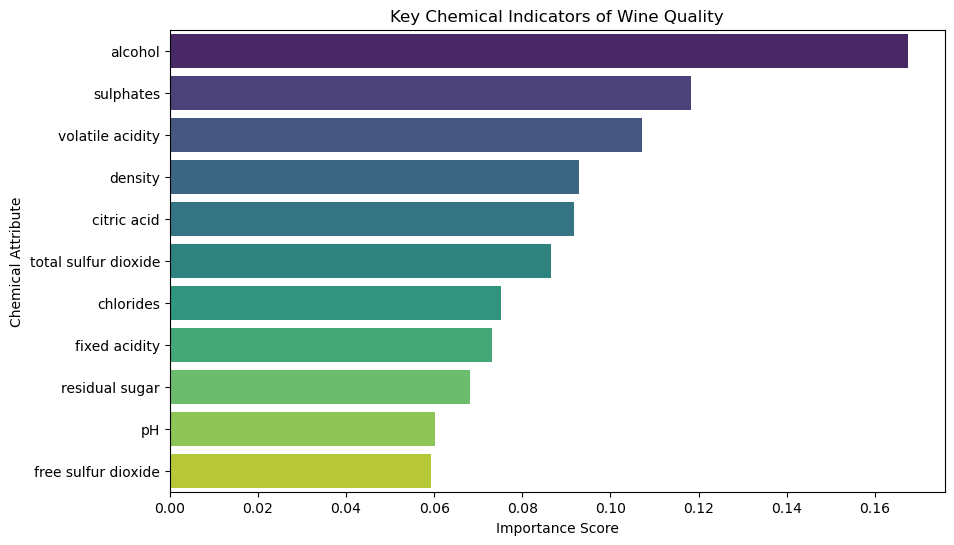

In [18]:
# 19. Plot Data (reverse-engineer)

# Note:
# Based on feature importance, Alcohol and Sulphates are generally strongest indicators of higher wine quality in this dataset!

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', hue='Feature', data=feature_importance, palette='viridis', legend=False)
plt.title('Key Chemical Indicators of Wine Quality')
plt.xlabel('Importance Score')
plt.ylabel('Chemical Attribute')
plt.show()